# ------- PART A - PYTHON CODING-------
# -------Q2. UNSUPERVISED LEARNING-----

# --- Task 1. Load and scale the data

In [1]:
# Importing Liabraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# To load data file
df = pd.read_csv(r"D:\Richa\BITSOM\Assignments'\2511416_Deshmukh_Richa_Assignment_04\ml-assessment-Richa-Deshmukh\data\q2_customers.csv")

# to scale all the features 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Scaling is essential for K-Means clustering because the algorithm relies on distance calculations. Features with larger magnitudes would dominate the clustering process if scaling is not applied.

# --- Task 2. Choosing K-Elbow meathod

C:\Users\Amardas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Amardas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Amardas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Amardas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the 

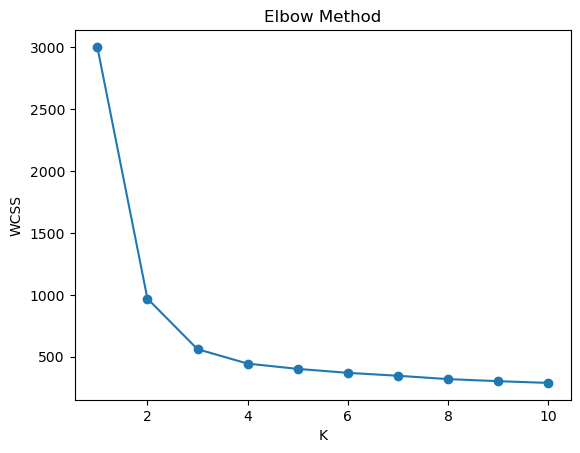

In [3]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

The elbow plot shows the relationship between the number of clusters and WCSS. The optimal number of clusters is chosen at the point where the rate of decrease sharply changes (elbow point), indicating diminishing returns.

In this case it is K = 3 approx.

# --- Task 3. K- means clustring

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])
print(centroids)

C:\Users\Amardas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


        age  annual_spend  visits_per_month  basket_size  \
0 -1.094595     -1.036122          1.114284    -0.934278   
1  1.132214      1.235574         -1.106680     1.253260   
2 -0.004449     -0.168055         -0.041370    -0.290670   

   days_since_last_visit  num_categories_purchased  
0              -0.813494                 -1.045346  
1               1.125725                  1.172991  
2              -0.287579                 -0.095968  


Each cluster represents a distinct customer segment. For example, one cluster may consist of high-spending frequent customers, while another may represent low-spending infrequent visitors. These insights can guide targeted marketing strategies.

# --- Task 4. Dimensionality Reduction with PCA

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_)

loadings = pd.DataFrame(pca.components_, columns=df.columns[:-1])
print(loadings)

Explained Variance: [0.83560354 0.05568764]
        age  annual_spend  visits_per_month  basket_size  \
0  0.411569       0.42154         -0.410399     0.412012   
1 -0.259432      -0.03327          0.208318    -0.195402   

   days_since_last_visit  num_categories_purchased  
0               0.378582                  0.414017  
1               0.911194                 -0.140479  


Principal components represent combinations of original features. PC1 captures the most variance in the data, while PC2 captures the second most. Feature loadings help interpret which variables contribute most to each component.

# --- Task 5. Cluster Visualization

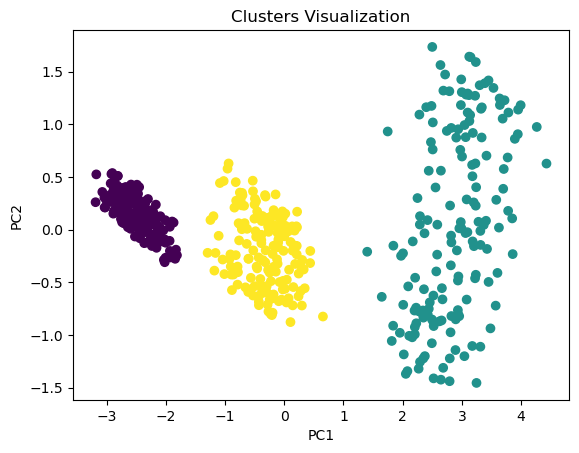

In [6]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters Visualization")
plt.show()